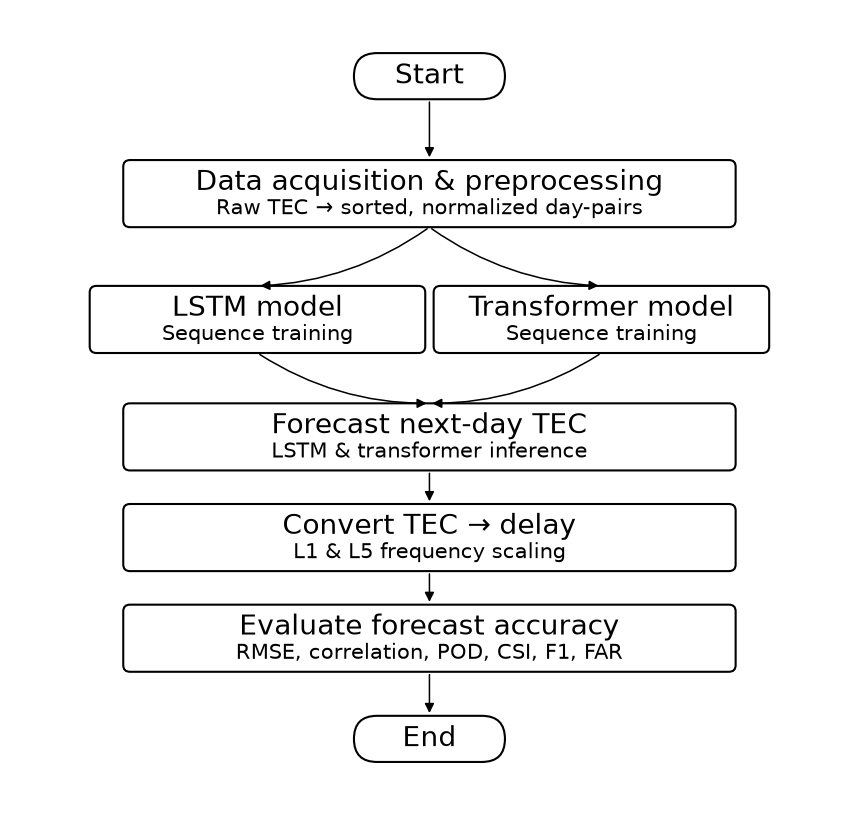

In [34]:
"""
Generates the TEC-based ionospheric delay forecasting workflow diagram.

Produces both a PNG (for quick viewing / slides) and a PDF (vector, for
direct inclusion in a LaTeX / Word manuscript) of the flowchart:

    Start
      -> Raw TEC observations
      -> Sort & aggregate
      -> Build supervised dataset
      -> (LSTM model | Transformer model)   [parallel branch]
      -> Forecast next-day TEC
      -> Convert TEC -> delay
      -> Evaluate forecast accuracy
      -> End

Run:
    python make_workflow_diagram.py
Outputs:
    tec_ionospheric_delay_workflow.png
    tec_ionospheric_delay_workflow.pdf
"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.path import Path
from src.configs.config import GENERATED_PLOTS_DIR



plt.rcParams["font.serif"] = ["Times New Roman"]

# ----------------------------------------------------------------------
# 1. Style constants
# ----------------------------------------------------------------------
FIG_W, FIG_H = 8.5, 9.5           # inches -> good aspect ratio for a paper figure
BOX_W, BOX_H = 7.3, 0.8           # default box size (data units)
SPLIT_BOX_W = 4                 # width of the LSTM / Transformer boxes
PILL_W, PILL_H = 1.8, 0.55        # Start / End pill size

COLORS = {
    "data":  {"face": "#FFFFFF", "edge": "#000000", "title": "#000000", "sub": "#000000"},
    "model": {"face": "#FFFFFF", "edge": "#000000", "title": "#000000", "sub": "#000000"},
    "proc":  {"face": "#FFFFFF", "edge": "#000000", "title": "#000000", "sub": "#000000"},
    "eval":  {"face": "#FFFFFF", "edge": "#000000", "title": "#000000", "sub": "#000000"},
    "pill":  {"face": "#FFFFFF", "edge": "#000000", "title": "#000000", "sub": "#000000"},
}

ARROW_COLOR = "#000000"
FONT_TITLE = dict(fontsize=20, fontweight="medium", ha="center", va="center")
FONT_SUB = dict(fontsize=15, ha="center", va="center")


# ----------------------------------------------------------------------
# 2. Helper drawing functions
# ----------------------------------------------------------------------
def draw_box(ax, cx, cy, w, h, title, subtitle, style_key, rounding=0.08):
    """Draw a rounded rectangle box with a title and an optional subtitle."""
    style = COLORS[style_key]
    box = FancyBboxPatch(
        (cx - w / 2, cy - h / 2), w, h,
        boxstyle=f"round,pad=0,rounding_size={rounding}",
        linewidth=1.5,
        facecolor=style["face"],
        edgecolor=style["edge"],
    )
    ax.add_patch(box)

    if subtitle:
        ax.text(cx, cy + 0.13, title, color=style["title"], **FONT_TITLE)
        ax.text(cx, cy - 0.18, subtitle, color=style["sub"], **FONT_SUB)
    else:
        ax.text(cx, cy, title, color=style["title"], **FONT_TITLE)


def draw_pill(ax, cx, cy, label):
    draw_box(ax, cx, cy, PILL_W, PILL_H, label, None, "pill", rounding=PILL_H / 2)


def draw_arrow(ax, start, end, connectionstyle="arc3,rad=0.0"):
    """Draw a clean arrow between two (x, y) points, stopping short of both ends."""
    arrow = FancyArrowPatch(
        start, end,
        connectionstyle=connectionstyle,
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.1,
        color=ARROW_COLOR,
        shrinkA=2, shrinkB=2,
    )
    ax.add_patch(arrow)


# ----------------------------------------------------------------------
# 3. Layout (all coordinates in a simple 0-10 x, 0-13 y data space)
# ----------------------------------------------------------------------
CX = 5.0  # center x for the main vertical spine

Y_START = 11.6
Y_PREP = 10.2
Y_MODELS = 8.7
Y_FORECAST = 7.3
Y_DELAY = 6.1
Y_EVAL = 4.9
Y_END = 3.7

X_LSTM = 2.95
X_TRANS = 7.05


def build_figure():
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    ax.set_xlim(0, 10)
    ax.set_ylim(2.9, 12.4)
    ax.axis("off")
    ax.set_aspect("equal")

    # ---- nodes -----------------------------------------------------
    draw_pill(ax, CX, Y_START, "Start")

    draw_box(ax, CX, Y_PREP, BOX_W, BOX_H,
              "Data acquisition & preprocessing",
              "Raw TEC \u2192 sorted, normalized day-pairs", "data")

    draw_box(ax, X_LSTM, Y_MODELS, SPLIT_BOX_W, BOX_H,
              "LSTM model",
              "Sequence training", "model")

    draw_box(ax, X_TRANS, Y_MODELS, SPLIT_BOX_W, BOX_H,
              "Transformer model",
              "Sequence training", "model")

    draw_box(ax, CX, Y_FORECAST, BOX_W, BOX_H,
              "Forecast next-day TEC",
              "LSTM & transformer inference", "proc")

    draw_box(ax, CX, Y_DELAY, BOX_W, BOX_H,
              "Convert TEC \u2192 delay",
              "L1 & L5 frequency scaling", "proc")

    draw_box(ax, CX, Y_EVAL, BOX_W, BOX_H,
              "Evaluate forecast accuracy",
              "RMSE, correlation, POD, CSI, F1, FAR", "eval")

    draw_pill(ax, CX, Y_END, "End")

    # ---- arrows ------------------------------------------------------
    draw_arrow(ax, (CX, Y_START - PILL_H / 2), (CX, Y_PREP + BOX_H / 2))

    # split
    draw_arrow(ax, (CX, Y_PREP - BOX_H / 2), (X_LSTM, Y_MODELS + BOX_H / 2),
               connectionstyle="arc3,rad=-0.15")
    draw_arrow(ax, (CX, Y_PREP - BOX_H / 2), (X_TRANS, Y_MODELS + BOX_H / 2),
               connectionstyle="arc3,rad=0.15")

    # merge
    draw_arrow(ax, (X_LSTM, Y_MODELS - BOX_H / 2), (CX, Y_FORECAST + BOX_H / 2),
               connectionstyle="arc3,rad=0.15")
    draw_arrow(ax, (X_TRANS, Y_MODELS - BOX_H / 2), (CX, Y_FORECAST + BOX_H / 2),
               connectionstyle="arc3,rad=-0.15")

    draw_arrow(ax, (CX, Y_FORECAST - BOX_H / 2), (CX, Y_DELAY + BOX_H / 2))
    draw_arrow(ax, (CX, Y_DELAY - BOX_H / 2), (CX, Y_EVAL + BOX_H / 2))
    draw_arrow(ax, (CX, Y_EVAL - BOX_H / 2), (CX, Y_END + PILL_H / 2))

    fig.tight_layout(pad=0.4)
    return fig

fig= build_figure()
fig.savefig(GENERATED_PLOTS_DIR/"workflowDiagram.png",format="png",dpi=300,bbox_inches="tight")